# Dimentionality Reduction


[Principal Component Analysis (PCA)](#scrollTo=lHWy51NEbMU_&line=1&uniqifier=1):
* Identifies the axes of maximum variance in the data and projects the data onto a lower-dimensional subspace.
* Linear method.

[t-SNE (t-Distributed Stochastic Neighbor Embedding)](#scrollTo=CjOE2Yp_bF9a&line=1&uniqifier=1)
* Non-linear technique for visualizing high-dimensional data by preserving the local structure.
* Often used for 2D or 3D visualization of data clusters.

[UMAP (Uniform Manifold Approximation and Projection)](#scrollTo=RRV1h6era_pl&line=1&uniqifier=1):
* Similar to t-SNE but computationally more efficient.
* Preserves both local and global structures of data, making it useful for visualizations and embeddings.


# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from pathlib import Path

# Dataset Loading

In [2]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/MobileDeviceUsage/') # replace with your path to the dataset!
fields_description_path = data_path/'info.txt'
dataset_path = data_path/'user_behavior_dataset.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path)
# Data Cleaning: Fill missing numeric values with zero for simplicity
df.fillna(0, inplace=True)
df.head(10)

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3
5,6,Google Pixel 5,Android,99,2.0,940,35,564,31,Male,2
6,7,Samsung Galaxy S21,Android,350,7.3,1802,66,1054,21,Female,4
7,8,OnePlus 9,Android,543,11.4,2956,82,1702,31,Male,5
8,9,Samsung Galaxy S21,Android,340,7.7,2138,75,1053,42,Female,4
9,10,iPhone 12,iOS,424,6.6,1957,75,1301,42,Male,4




---



In [4]:
print(fields_description)

User ID: Unique identifier for each user.
Device Model: Model of the user's smartphone.
Operating System: The OS of the device (iOS or Android).
App Usage Time: Daily time spent on mobile applications, measured in minutes.
Screen On Time: Average hours per day the screen is active.
Battery Drain: Daily battery consumption in mAh.
Number of Apps Installed: Total apps available on the device.
Data Usage: Daily mobile data consumption in megabytes.
Age: Age of the user.
Gender: Gender of the user (Male or Female).
User Behavior Class: Classification of user behavior based on usage patterns (1 to 5).


In [5]:
numeric_features = ['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)',
                    'Number of Apps Installed', 'Data Usage (MB/day)', 'Age']
X = df[numeric_features].fillna(0)
target_name = 'User Behavior Class'
y = df[target_name]

X_scaled = StandardScaler().fit_transform(X)

In [6]:
X_scaled

array([[ 0.6882558 ,  0.36762618,  0.42372605,  0.60609597,  0.30040456,
         0.12638294],
       [-0.01766827, -0.18677143, -0.23719786, -0.32244114,  0.02227699,
         0.70950576],
       [-0.66147102, -0.4150528 , -0.93355023, -0.69385599, -0.94960697,
         0.29298946],
       ...,
       [-0.97207762, -0.70855742, -0.71242781, -1.06527083, -0.73866752,
         0.95941554],
       [-1.18103114, -1.16512016, -1.33670159, -1.39954419, -1.10273338,
         0.45959598],
       [-0.33392226,  0.04150994, -0.26773963, -0.06245075, -0.15897468,
        -1.28977246]])

# Principal Component Analysis (PCA)

Time taken for PCA: 0.03 seconds


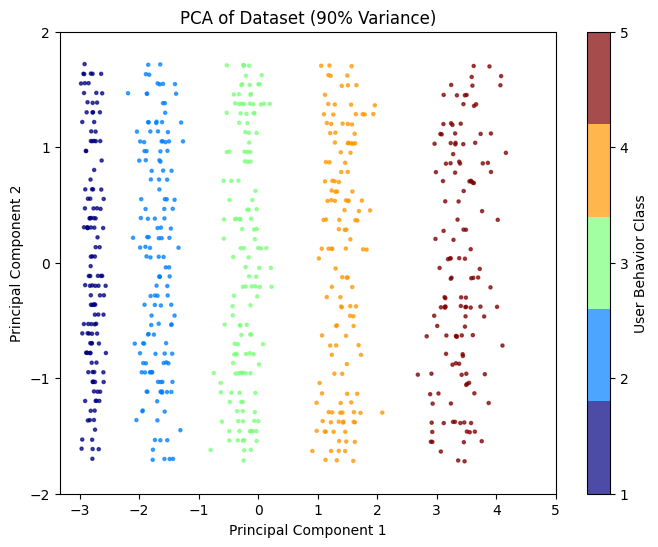

In [7]:
# Step 3: Principal Component Analysis (PCA)
import time
start_time = time.time()
pca = PCA(n_components=0.9)  # Keep 90% of variance
X_pca = pca.fit_transform(X_scaled)
end_time = time.time()
print(f'Time taken for PCA: {end_time - start_time:.2f} seconds')

# Plot PCA results
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap('jet', np.max(y) - np.min(y) + 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.7, s=5, cmap=cmap, vmin=min(y.unique()), vmax=max(y.unique()))
cbar = plt.colorbar(scatter, ticks=sorted(y.unique()))  # Set colorbar ticks to unique values of y
cbar.set_label(target_name)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Dataset (90% Variance)')
plt.xticks(range(int(X_pca[:, 0].min()) - 1, int(X_pca[:, 0].max()) + 2))  # Set x-axis ticks to integer values
plt.yticks(range(int(X_pca[:, 1].min()) - 1, int(X_pca[:, 1].max()) + 2))  # Set y-axis ticks to integer values
plt.show()



In [8]:
# show the variance explained with 2 components:
print(f'Variance explained by the first component: {pca.explained_variance_ratio_[0]:.2f}')
print(f'Variance explained by the second component: {pca.explained_variance_ratio_[1]:.2f}')
# number of components to explain 90% variance
print(f'Number of components to explain 90% variance: {pca.n_components_}')

Variance explained by the first component: 0.80
Variance explained by the second component: 0.17
Number of components to explain 90% variance: 2


# t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [9]:
import time
start_time = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=50.0, early_exaggeration=15.0)
X_tsne = tsne.fit_transform(X_scaled)
end_time = time.time()
print(f'Time taken for t-SNE: {end_time - start_time:.2f} seconds')

Time taken for t-SNE: 7.68 seconds


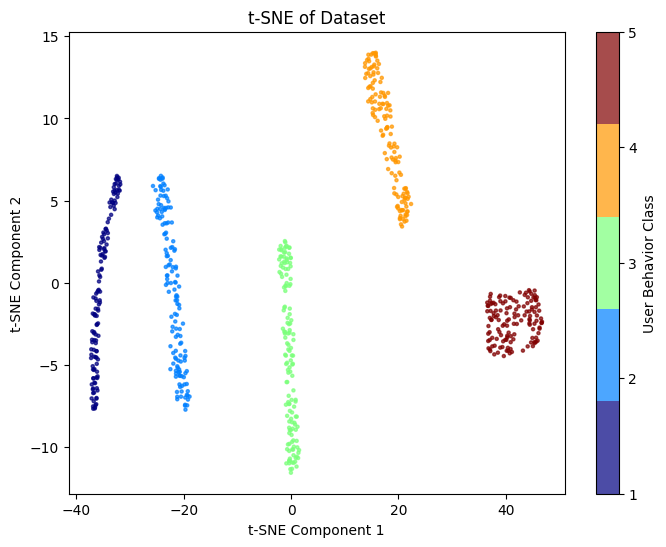

In [10]:
# Plot t-SNE results
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap('jet', np.max(y) - np.min(y) + 1)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, alpha=0.7, s=5, cmap=cmap, vmin=min(y.unique()), vmax=max(y.unique()))
cbar = plt.colorbar(scatter, ticks=sorted(y.unique()))  # Set colorbar ticks to unique values of y
cbar.set_label(target_name)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Dataset')
plt.show()

# UMAP (Uniform Manifold Approximation and Projection)

In [11]:
! pip install umap-learn

In [12]:
import umap
import time

start_time = time.time()
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10)
X_umap = umap_reducer.fit_transform(X_scaled)
end_time = time.time()
print(f'Time taken for UMAP: {end_time - start_time:.2f} seconds')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Time taken for UMAP: 11.63 seconds


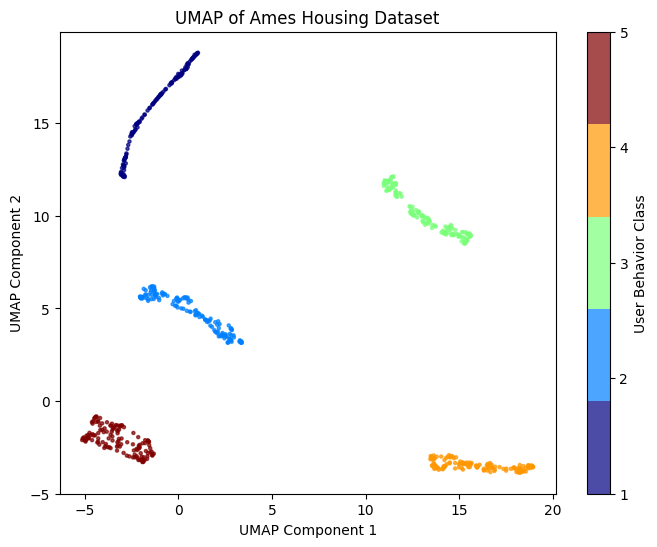

In [13]:
# Plot UMAP results
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap('jet', np.max(y) - np.min(y) + 1)
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, alpha=0.7, s=5, cmap=cmap, vmin=min(y.unique()), vmax=max(y.unique()))
cbar = plt.colorbar(scatter, ticks=sorted(y.unique()))  # Set colorbar ticks to unique values of y
cbar.set_label(target_name)

plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP of Ames Housing Dataset')
plt.show()